# Анализ системы метрик приложения

Даны данные приложения Procrastinate Pro+, которое предоставляет пользователям доступ к развлекательному контенту. 

### Данные

В вашем распоряжении есть данные о посещениях приложения, покупках и расходах на маркетинг.

1. Датасет с информацией о посещениях приложения пользователями, которые зарегистрировались с 1 апреля 2024 года по 30 ноября 2024 года.

2. Датасет с информацией о покупках.

3. Датасет с информацией о затратах на маркетинг.
    



## Загрузка и предобработка данных



In [1]:
#Загрузка необходимых библиотек
import pandas as pd
import numpy as np
import seaborn as sns
import matplotlib.pyplot as plt
import matplotlib.colors as mcolors

In [2]:
# Создание датафреймов для трёх таблиц
df_users = pd.read_csv('_____.csv')
df_events = pd.read_csv('____.csv')
df_costs = pd.read_csv('_____s.csv')

# Вывод на экран размер исходных таблиц
display(df_users.shape, df_events.shape, df_costs.shape)

(161865, 6)

(33893, 3)

(976, 3)

In [3]:
#Изучение данных датафрейма
def data_overview(df):
    # Вывод первых 5 строк
    display('Первые 5 строк:')
    display(df.head())
    
    # info()
    display('Информация о DataFrame:')
    display(df.info())
    
    # Пропуски абсолютные и относительные
    display('Пропуски:')
    missing = df.isnull().sum()
    display('Абсолютные пропуски:')
    display(missing)
    display('Относительные пропуски:')
    display(missing / len(df) * 100)
    
    # Распределение данных количественных столбцов
    display('Распределение данных количественных столбцов:')
    numeric_cols = df.select_dtypes(include=[np.number]).columns
    for col in numeric_cols:
        display(f'{col}:')
        display(df[col].describe())
    
    # Уникальные значения в категориальных столбцах
    display('Уникальные значения в категориальных столбцах:')
    categorical_cols = df.select_dtypes(include=['object', 'category']).columns
    for col in categorical_cols:
        display(f'{col}:')
        display(df[col].unique())
    
    # Проверка явных дубликатов
    display('Проверка явных дубликатов:')
    duplicates = df[df.duplicated()]
    if duplicates.empty:
        display('Дубликатов нет.')
    else:
        display('Есть дубликаты:')
        display(duplicates)

In [92]:
# Применяем функцию для знакомства с df_users
# data_overview(df_users)

In [5]:
#Проверка дубликатов в стобцах user_id, session_start, session_end
duplicates1 = df_users.duplicated(subset=['user_id', 'session_start', 'session_end']).sum()
display(duplicates1)

0

In [93]:
# Применяем функцию для знакомства с df_events
# data_overview(df_events)

In [7]:
#Проверка дубликатов в стобцах user_id, event_dt
duplicates2 = df_events.duplicated(subset=['user_id', 'event_dt']).sum()
display(duplicates2)

0

In [94]:
# Применяем функцию для знакомства с df_costs
# data_overview(df_costs)

In [9]:
#Проверка дубликатов в стобцах dt, channel
duplicates3 = df_costs.duplicated(subset=['dt', 'channel']).sum()
display(duplicates3)

0

В данных представлен регион Индия, период с `2024-04-01` по `2024-11-30`, типы device: `desktop`, `tv`, `mobile`, источники привлечения:`MediaTornado`, `RocketSuperAds`, `FaceBoom`, `TipTop`.

Во всех датафреймах нет ни пропусков, ни дубликатов. Столбцы `session_start`, `session_end`, `event_dt`, `dt` тип данных object, нужно преобразовать в datetime. 

In [10]:
for column in ['session_start', 'session_end']:
    df_users[column] = pd.to_datetime(df_users[column])

In [11]:
df_events['event_dt'] = pd.to_datetime(df_events['event_dt'])

In [12]:
df_costs['dt'] = pd.to_datetime(df_costs['dt'])

In [13]:
df_users['user_id'].nunique()

74856

## Подготовка данных к когортному анализу



In [14]:
#Создание нового датафрейма profiles 
profiles = df_users.sort_values(['user_id','session_start']).groupby('user_id', as_index=False).agg(first_dt=('session_start', 
                                                        'first'), first_channel = ('channel', 'first'))

In [15]:
#Нормализация типа данных столбца first_dt
profiles['first_dt']=profiles['first_dt'].dt.normalize()


In [16]:
#Подсчет количества user_id по первой дате и первому каналу
users_count = profiles.groupby(['first_dt','first_channel'])['user_id'].nunique().reset_index()


In [17]:
#Переименование столбца
users_count = users_count.rename(columns = {'user_id':'count'})

In [18]:
#Для объяединения таблиц, приведем к нужному типу dt
df_costs['dt'] = df_costs['dt'].dt.normalize()

In [19]:
#Присоединение таблицы для подсчета CAC
cac = users_count.merge(df_costs, left_on =['first_dt','first_channel'], right_on= ['dt', 'channel'], how='left')  


In [20]:
#Расчет CAC
cac['CAC'] = cac['costs']/cac['count']


In [21]:
#Присоединение столбца CAC к таблице profiles
profiles = profiles.merge(cac[['first_dt','first_channel', 'CAC']], on=['first_dt','first_channel'], 
                          how='left').reset_index(drop=True)


In [22]:
#Присоедение столбцов к df_users
df_users=pd.merge(df_users, profiles, on='user_id', how='left')
df_users.head()

,user_id,region,device,channel,session_start,session_end,first_dt,first_channel,CAC
0,631105188566,India,desktop,MediaTornado,2024-04-01 03:48:00,2024-04-01 04:19:00,2024-04-01,MediaTornado,0.249160
1,892885906464,India,tv,RocketSuperAds,2024-04-01 00:47:00,2024-04-01 01:14:00,2024-04-01,RocketSuperAds,0.886429
2,517003690029,India,mobile,MediaTornado,2024-04-01 17:31:00,2024-04-01 17:53:00,2024-04-01,MediaTornado,0.249160
3,185156659289,India,mobile,MediaTornado,2024-04-01 14:36:00,2024-04-01 14:51:00,2024-04-01,MediaTornado,0.249160
4,409503040345,India,mobile,RocketSuperAds,2024-04-01 08:25:00,2024-04-01 08:45:00,2024-04-01,RocketSuperAds,0.886429


In [23]:
# Расчет лайфтайма с первого дня активности пользователя до текущего дня
df_users['n_period'] = (df_users['session_start'].dt.normalize() - df_users['first_dt']).dt.days.astype(int)


In [24]:
df_events['event_dt'] = df_events['event_dt'].dt.normalize()


In [25]:
#Присоединение данных для подсчета лайфтайма покупок
df_events = df_events.merge(profiles, on='user_id',how='left')


In [26]:
# Расчет лайфтайма с первого дня активности пользователя до совершения покупок
df_events['n_period'] = (df_events['event_dt'].dt.normalize() - df_events['first_dt']).dt.days.astype(int)


## Анализ месячной динамики основных метрик продукта



**Рассчет DAU, MAU, Stickiness.**

In [27]:
df_users['session_start'] = df_users['session_start'].dt.to_period('D')

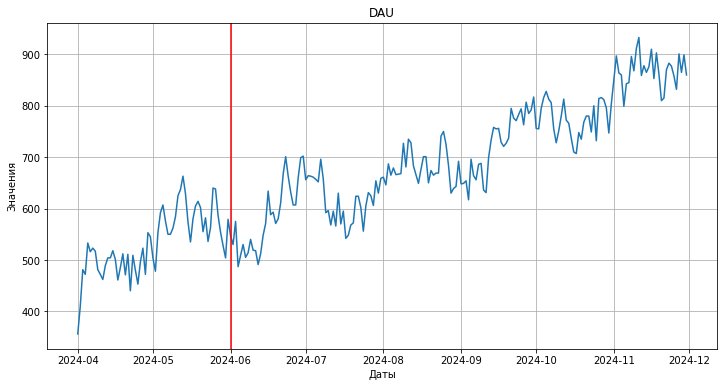

In [28]:
#Расчет DAU и визуализиция
dau = df_users.groupby('session_start')['user_id'].nunique().reset_index()
dau['session_start'] = dau['session_start'].dt.to_timestamp()
# строим график в matplotlib
plt.subplots(figsize=(12,6))
plt.plot(dau['session_start'], dau['user_id'])
plt.title('DAU')
plt.xlabel('Даты')
plt.ylabel('Значения')
# покажем красной линией июнь 2024 года появление нового контента
plt.axvline(x = pd.Timestamp('2024-06-01'), color='red')
plt.grid()
plt.show()

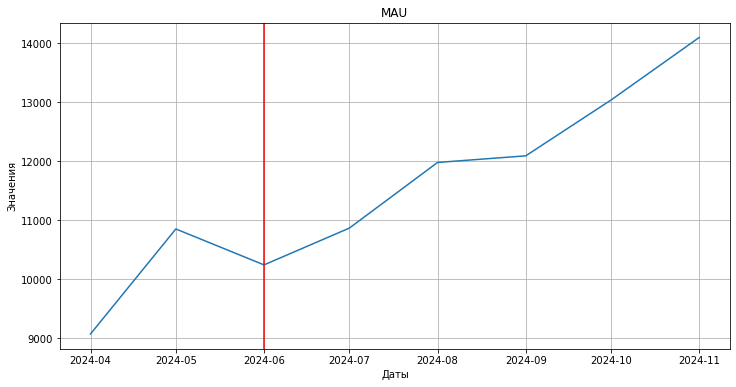

In [29]:
# Конвертация столбца session_start в месяц
df_users['month'] = df_users['session_start'].dt.to_timestamp().dt.to_period('M')
#Расчет MAU и визуализация
mau = df_users.groupby('month')['user_id'].nunique().reset_index()
mau['month'] = mau['month'].dt.to_timestamp()
# строим график в matplotlib
plt.subplots(figsize=(12,6))
plt.plot(mau['month'], mau['user_id'])
plt.title('MAU')
plt.xlabel('Даты')
plt.ylabel('Значения')
# покажем красной линией июнь 2024 года появление нового контента
plt.axvline(x = pd.Timestamp('2024-06-01'), color='red')
plt.grid()
plt.show()

In [30]:
#Расчет Stickiness
dau = df_users.groupby('session_start')['user_id'].nunique().reset_index()

dau['session_start'] = dau['session_start'].dt.to_timestamp()
dau['month'] = dau['session_start'].dt.to_period('M').dt.to_timestamp()

dau_monthly_average = dau.groupby('month')['user_id'].mean().reset_index()
mau = df_users.groupby('month')['user_id'].nunique().reset_index()
mau['month'] = mau['month'].dt.to_timestamp()
stickiness_table = pd.merge(dau_monthly_average, mau, on='month', how='left')
stickiness_table['stick'] = 100 * (stickiness_table['user_id_x']/stickiness_table['user_id_y'])
stickiness_table

,month,user_id_x,user_id_y,stick
0,2024-04-01,488.333333,9069,5.384644
1,2024-05-01,576.967742,10849,5.318165
2,2024-06-01,580.366667,10240,5.667643
3,2024-07-01,615.000000,10864,5.660898
4,2024-08-01,681.193548,11977,5.687514
5,2024-09-01,724.100000,12089,5.989743
6,2024-10-01,773.193548,13036,5.931218
7,2024-11-01,868.133333,14097,6.158284


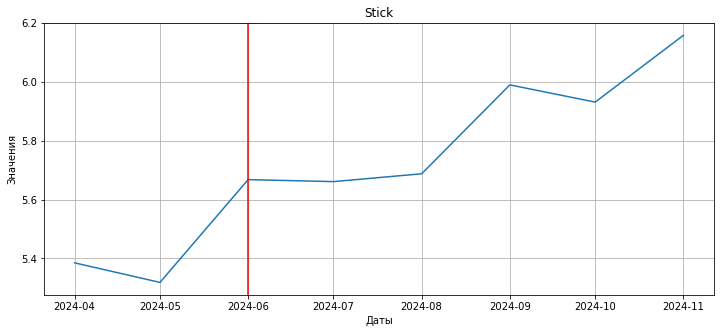

In [31]:
# строим график в matplotlib
plt.subplots(figsize=(12,5))
plt.plot(stickiness_table['month'], stickiness_table['stick'])
plt.title('Stick')
plt.xlabel('Даты')
plt.ylabel('Значения')
# покажем красной линией июнь 2024 года появление нового контента
plt.axvline(x = pd.Timestamp('2024-06-01'), color='red')
plt.grid()
plt.show()

По графикам виден рост как дневных, так и месячных показателей. Stickiness показывает, что доля ежедневно возвращающихся пользователей относительно месячной аудитории повысилась, повышение вовлеченности пользователей и привыкание к продукту. MAU заметно растет с начала лета с появлением нового контента.

**Расчет среднего CAC, LTV и ROI.**

In [32]:
profiles['month'] = profiles['first_dt'].dt.to_period('M')

In [33]:
#Расчет среднего CAC
CAC_mean = profiles.groupby('month').agg(
    total_users = ('user_id','nunique'),
    avg_cac = ('CAC','mean'),
).reset_index()
CAC_mean

,month,total_users,avg_cac
0,2024-04,9069,0.734706
1,2024-05,9789,0.748572
2,2024-06,8719,0.973978
3,2024-07,8742,1.054344
4,2024-08,9518,1.155601
5,2024-09,9198,1.178301
6,2024-10,9520,1.323047
7,2024-11,10301,1.320148


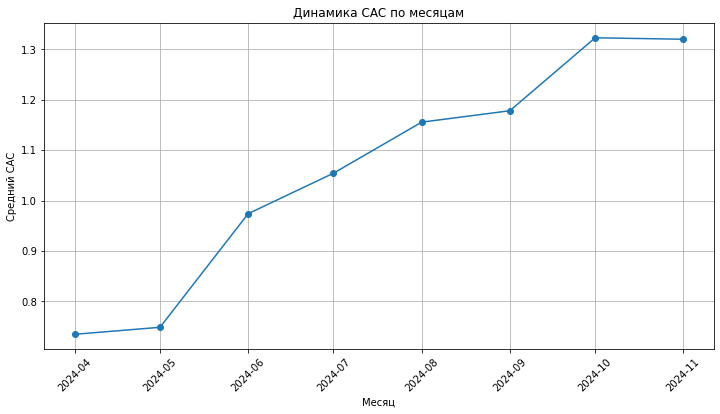

In [34]:
CAC_mean['month'] = CAC_mean['month'].dt.to_timestamp()
# Построение графика
plt.figure(figsize=(12, 6))
plt.plot(CAC_mean['month'], CAC_mean['avg_cac'], marker='o')
plt.xticks(rotation=45)
plt.xlabel('Месяц')
plt.ylabel('Средний CAC')
plt.title('Динамика CAC по месяцам')
plt.grid(True)
plt.show()

In [35]:
# Фильтрация покупок в диапазоне 0–28 дней
events_28 = df_events[df_events['n_period'] < 28].reset_index(drop=True)


In [36]:
events_28['month'] = events_28['first_dt'].dt.to_period('M').dt.to_timestamp()

In [37]:
#Создание таблицы LTV
LTV = events_28.groupby('month')['revenue'].sum().reset_index(name='revenue_28')
LTV

,month,revenue_28
0,2024-04-01,7425.63
1,2024-05-01,8141.76
2,2024-06-01,7447.84
3,2024-07-01,9991.41
4,2024-08-01,10367.05
5,2024-09-01,10085.88
6,2024-10-01,11449.71
7,2024-11-01,8893.98


In [38]:
#Присоединение таблиц для расчета ROI
ROI = pd.merge(LTV, CAC_mean, on='month', how='left')
ROI

,month,revenue_28,total_users,avg_cac
0,2024-04-01,7425.63,9069,0.734706
1,2024-05-01,8141.76,9789,0.748572
2,2024-06-01,7447.84,8719,0.973978
3,2024-07-01,9991.41,8742,1.054344
4,2024-08-01,10367.05,9518,1.155601
5,2024-09-01,10085.88,9198,1.178301
6,2024-10-01,11449.71,9520,1.323047
7,2024-11-01,8893.98,10301,1.320148


In [39]:
# Считаем LTV на 28 день
ROI['LTV'] = ROI['revenue_28'] / ROI['total_users']
ROI

,month,revenue_28,total_users,avg_cac,LTV
0,2024-04-01,7425.63,9069,0.734706,0.818793
1,2024-05-01,8141.76,9789,0.748572,0.831725
2,2024-06-01,7447.84,8719,0.973978,0.854208
3,2024-07-01,9991.41,8742,1.054344,1.142920
4,2024-08-01,10367.05,9518,1.155601,1.089205
5,2024-09-01,10085.88,9198,1.178301,1.096530
6,2024-10-01,11449.71,9520,1.323047,1.202701
7,2024-11-01,8893.98,10301,1.320148,0.863409


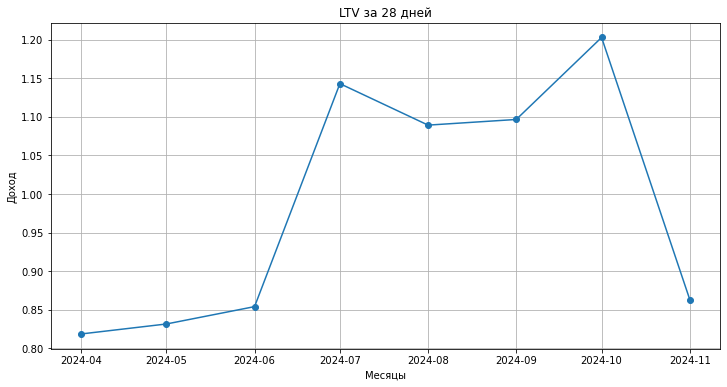

In [40]:

# Строим график LTV
plt.figure(figsize=(12, 6))
plt.plot(ROI['month'], ROI['LTV'], marker='o')
plt.title('LTV за 28 дней')
plt.xlabel('Месяцы')
plt.ylabel('Доход')
plt.grid(True)
plt.show()

In [41]:
#Расчет ROI
ROI['ROI'] = (ROI['LTV']-ROI['avg_cac'])/ROI['avg_cac'] * 100
ROI

,month,revenue_28,total_users,avg_cac,LTV,ROI
0,2024-04-01,7425.63,9069,0.734706,0.818793,11.444870
1,2024-05-01,8141.76,9789,0.748572,0.831725,11.108209
2,2024-06-01,7447.84,8719,0.973978,0.854208,-12.297015
3,2024-07-01,9991.41,8742,1.054344,1.142920,8.401051
4,2024-08-01,10367.05,9518,1.155601,1.089205,-5.745639
5,2024-09-01,10085.88,9198,1.178301,1.096530,-6.939783
6,2024-10-01,11449.71,9520,1.323047,1.202701,-9.096121
7,2024-11-01,8893.98,10301,1.320148,0.863409,-34.597554


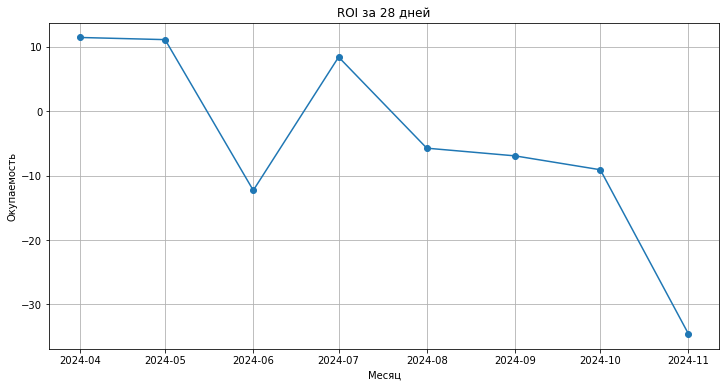

In [42]:

# Строим ROI
plt.figure(figsize=(12, 6))
plt.plot(ROI['month'], ROI['ROI'], marker='o')
plt.title('ROI за 28 дней')
plt.xlabel('Месяц')
plt.ylabel('Окупаемость')
plt.grid(True)
plt.show()

Несмотря на рост DAU, MAU, Stickiness, экономическая эффективность маркетинга ухудшается. CAC растет, LTV растет, ROI падает, вложения в привлечение окупаются хуже. 
После запуска канала CAC продолжил рости. LTV до июля рос, до августа небольшой спад и снова рост, но пошел на снижение в октябре. ROI снижается. В июне повысился до положительного значения, что хорошо, но в августе уже отрицательное значение, которое сохраняется до конца исследуемого периода.

## Анализ метрик в разрезе источника привлечения

In [43]:
#Посчитаем количество уникальных пользователей по источникам привлечения
user_channel = profiles.groupby('first_channel')['user_id'].nunique()
user_channel

first_channel
FaceBoom          28401
MediaTornado      14080
RocketSuperAds    14257
TipTop            18118
Name: user_id, dtype: int64

Большое количество пользователей из источников FaceBoom и TipTop.

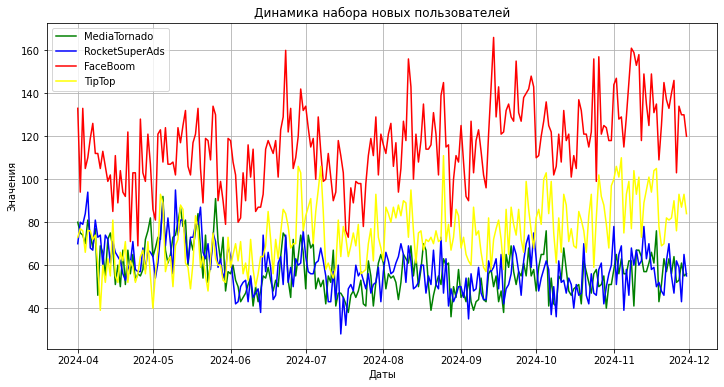

In [44]:
#Определение динамики набора новых пользователей
dinamika = df_users[df_users['n_period']==0].groupby(['first_dt','first_channel'])['user_id'].count().reset_index()
# строим график в matplotlib
plt.subplots(figsize=(12,6))
plt.plot(dinamika[dinamika['first_channel'] == 'MediaTornado']['first_dt'], 
         dinamika[dinamika['first_channel'] == 'MediaTornado']['user_id'], color='green')
plt.plot(dinamika[dinamika['first_channel'] == 'RocketSuperAds']['first_dt'], 
         dinamika[dinamika['first_channel'] == 'RocketSuperAds']['user_id'], color='blue')
plt.plot(dinamika[dinamika['first_channel'] == 'FaceBoom']['first_dt'], 
         dinamika[dinamika['first_channel'] == 'FaceBoom']['user_id'], color='red')
plt.plot(dinamika[dinamika['first_channel'] == 'TipTop']['first_dt'], 
         dinamika[dinamika['first_channel'] == 'TipTop']['user_id'], color='yellow')
plt.title('Динамика набора новых пользователей')
plt.legend(['MediaTornado', 'RocketSuperAds', 'FaceBoom', 'TipTop'])
plt.xlabel('Даты')
plt.ylabel('Значения')
plt.grid()
plt.show()

FaceBoom - массовый канал привлечения, приводит наибольший объем пользователей. Следующую строчку занимает TipTop. MediaTornado и RocketSuperAds похожие показатели. 


In [45]:
#Расчет DAU
dau_channel = df_users.groupby(['session_start', 'first_channel'])['user_id'].nunique().reset_index()
dau_channel['session_start'] = dau_channel['session_start'].dt.to_timestamp()


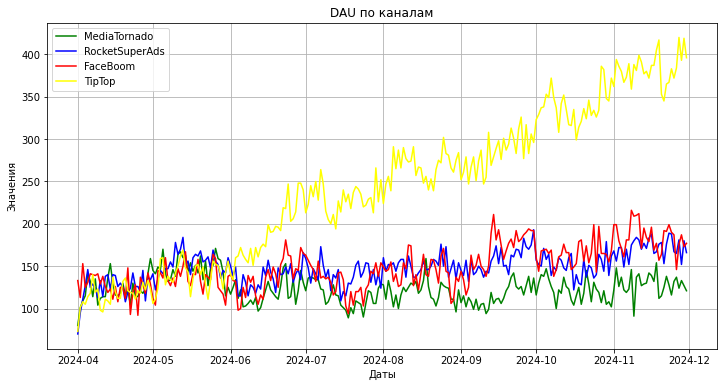

In [46]:
# строим график в matplotlib
plt.subplots(figsize=(12,6))
plt.plot(dau_channel[dau_channel['first_channel'] == 'MediaTornado']['session_start'], 
         dau_channel[dau_channel['first_channel'] == 'MediaTornado']['user_id'], color='green')
plt.plot(dau_channel[dau_channel['first_channel'] == 'RocketSuperAds']['session_start'], 
         dau_channel[dau_channel['first_channel'] == 'RocketSuperAds']['user_id'], color='blue')
plt.plot(dau_channel[dau_channel['first_channel'] == 'FaceBoom']['session_start'], 
         dau_channel[dau_channel['first_channel'] == 'FaceBoom']['user_id'], color='red')
plt.plot(dau_channel[dau_channel['first_channel'] == 'TipTop']['session_start'], 
         dau_channel[dau_channel['first_channel'] == 'TipTop']['user_id'], color='yellow')
plt.title('DAU по каналам')
plt.legend(['MediaTornado', 'RocketSuperAds', 'FaceBoom', 'TipTop'])
plt.xlabel('Даты')
plt.ylabel('Значения')
plt.grid()
plt.show()

In [47]:
#Расчет MAU и визуализация
df_users['month'] = df_users['session_start'].dt.to_timestamp().dt.to_period('M')
mau_channel = df_users.groupby(['month', 'first_channel'])['user_id'].nunique().reset_index()
mau_channel['month'] = mau_channel['month'].dt.to_timestamp()


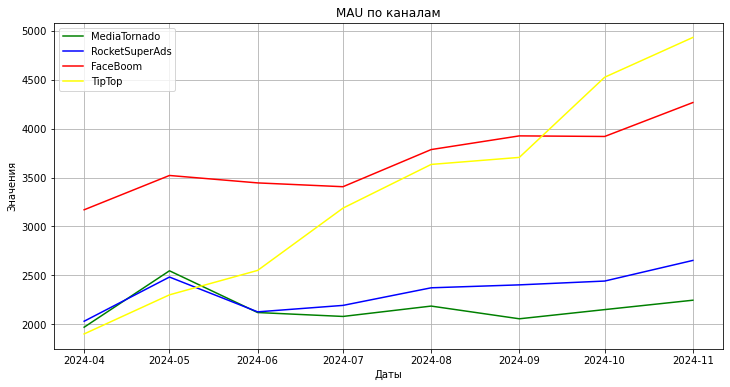

In [48]:
# строим график в matplotlib
plt.subplots(figsize=(12,6))
plt.plot(mau_channel[mau_channel['first_channel'] == 'MediaTornado']['month'], 
         mau_channel[mau_channel['first_channel'] == 'MediaTornado']['user_id'], color='green')
plt.plot(mau_channel[mau_channel['first_channel'] == 'RocketSuperAds']['month'], 
         mau_channel[mau_channel['first_channel'] == 'RocketSuperAds']['user_id'], color='blue')
plt.plot(mau_channel[mau_channel['first_channel'] == 'FaceBoom']['month'], 
         mau_channel[mau_channel['first_channel'] == 'FaceBoom']['user_id'], color='red')
plt.plot(mau_channel[mau_channel['first_channel'] == 'TipTop']['month'], 
         mau_channel[mau_channel['first_channel'] == 'TipTop']['user_id'], color='yellow')
plt.title('MAU по каналам')
plt.legend(['MediaTornado', 'RocketSuperAds', 'FaceBoom', 'TipTop'])
plt.xlabel('Даты')
plt.ylabel('Значения')
plt.grid()
plt.show()

In [49]:
#Расчет Stickiness
dau_channel['month'] = dau_channel['session_start'].dt.to_period('M').dt.to_timestamp()

dau_monthly_channel = dau_channel.groupby(['month', 'first_channel'])['user_id'].mean().reset_index()

stickiness_table_channel = pd.merge(mau_channel, dau_monthly_channel, on=['month', 'first_channel'], how='left')
stickiness_table_channel['stick'] = round(100 * (stickiness_table_channel['user_id_y']/stickiness_table_channel['user_id_x']),2)


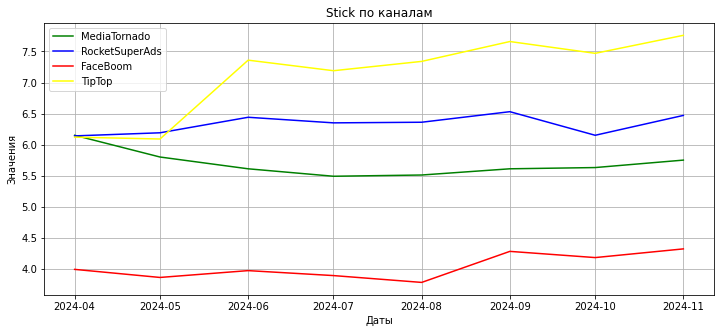

In [50]:
plt.subplots(figsize=(12,5))
plt.plot(stickiness_table_channel[stickiness_table_channel['first_channel'] == 'MediaTornado']['month'], 
         stickiness_table_channel[stickiness_table_channel['first_channel'] == 'MediaTornado']['stick'], color='green')
plt.plot(stickiness_table_channel[stickiness_table_channel['first_channel'] == 'RocketSuperAds']['month'], 
         stickiness_table_channel[stickiness_table_channel['first_channel'] == 'RocketSuperAds']['stick'], color='blue')
plt.plot(stickiness_table_channel[stickiness_table_channel['first_channel'] == 'FaceBoom']['month'], 
         stickiness_table_channel[stickiness_table_channel['first_channel'] == 'FaceBoom']['stick'], color='red')
plt.plot(stickiness_table_channel[stickiness_table_channel['first_channel'] == 'TipTop']['month'], 
         stickiness_table_channel[stickiness_table_channel['first_channel'] == 'TipTop']['stick'], color='yellow')
plt.title('Stick по каналам')
plt.legend(['MediaTornado', 'RocketSuperAds', 'FaceBoom', 'TipTop'])
plt.xlabel('Даты')
plt.ylabel('Значения')
plt.grid()
plt.show()

За исследуемый период лидером по динамике роста TipTop. FaceBoom показывает низкий результат Stickiness, при том что MAU довольно высок по отношению к другим каналам, что показывает слабое ежедневное удержание. В отличие от TipTop, где люди возвращаются ежедневно.

In [51]:
#Добавление недельной когорты  
df_users['first_week'] = df_users['first_dt'].dt.to_period('W')


In [52]:
#Фильтрация df_users 28 дней
users_28 = df_users[df_users['n_period']<28]

In [53]:
#Сортировка
users_28=users_28.sort_values(by=['user_id', 'n_period'])


In [54]:
#Подсчет количества людей в когортах по каналам
users_28d = users_28[users_28['n_period']==0].groupby(['first_week', 'first_channel'])['user_id'].nunique().reset_index(name='user_count')


In [55]:
#Фильтрация 14-28 день
users_28_14 = users_28[users_28['n_period'] >= 14]

In [56]:
#Подсчет количества пользователей с 14-28 день
users_28_14 = users_28_14.groupby(['first_week', 'first_channel'])['user_id'].nunique().reset_index(name='is_active_14_28')


In [57]:
#Создание df для подсчета скользящего удержания
RR = pd.merge(users_28d, users_28_14, on=['first_week','first_channel'], how='left')

In [58]:
#Подсчет скольщего удержания
RR['RR'] = RR['is_active_14_28']/RR['user_count']

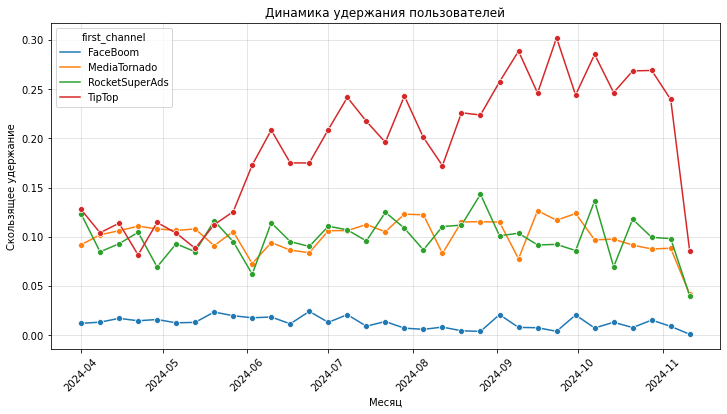

In [59]:
RR['first_week']=RR['first_week'].dt.to_timestamp()
plt.figure(figsize=(12, 6))

# Строим линейный график 
sns.lineplot(
    data=RR,
    x='first_week',
    y='RR',
    hue='first_channel',
    marker='o'
)

# Оформляем график
plt.grid(alpha=.4)
plt.xticks(rotation=45)

# Добавляем подписи осей
plt.xlabel('Месяц')
plt.ylabel('Скользящее удержание')

# Добавляем заголовок
plt.title('Динамика удержания пользователей')
plt.show()

- TipTop показывает отличную динамику. Около июня наблюдается рост, но в ноябре спад.
- FaceBoom очень низкий уровень без колебаний. Пользователи правктически не возвращаются после первого визита.
- RocketSuperAds и MediaTornado находятся на одном уровне, динамика практически синхронная.

In [60]:
#Создание когорты для events_28
events_28['first_week'] = events_28['first_dt'].dt.to_period('W')


In [61]:
#Сортировка по прользователю и лайфтайму
events_28=events_28.sort_values(by=['user_id', 'n_period'])


In [62]:
#Подсчет количества платящих пользователей
events_28d = events_28.groupby(['first_week', 'first_channel'])['user_id'].nunique().reset_index(name='paid_user')


In [63]:
#Создание df для подсчета конверсии
merge_28 = pd.merge(users_28d, events_28d, on=['first_week', 'first_channel'], how='left')


In [64]:
#Подсчет конверсии в покупку
merge_28['CR'] = merge_28['paid_user']/merge_28['user_count']


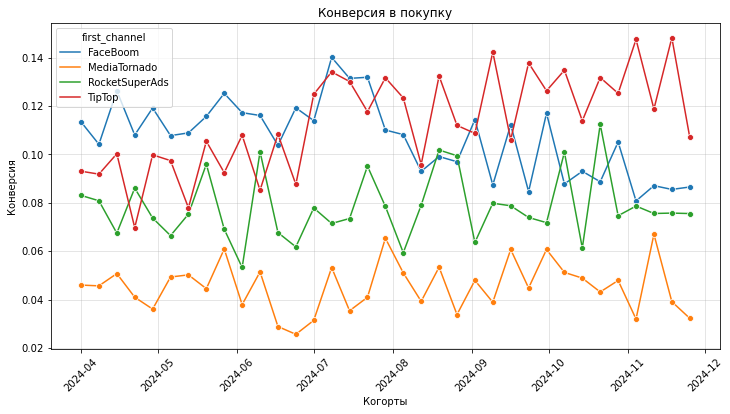

In [65]:
merge_28['first_week']=merge_28['first_week'].dt.to_timestamp()
plt.figure(figsize=(12, 6))

# Строим линейный график 
sns.lineplot(
    data=merge_28,
    x='first_week',
    y='CR',
    hue='first_channel',
    marker='o'
)

# Оформляем график
plt.grid(alpha=.4)
plt.xticks(rotation=45)

# Добавляем подписи осей
plt.xlabel('Когорты')
plt.ylabel('Конверсия')

# Добавляем заголовок
plt.title('Конверсия в покупку')
plt.show()

In [66]:
cac['first_week'] = cac['first_dt'].dt.to_period('W').dt.to_timestamp()

In [67]:
week_costs = cac.groupby(['first_week', 'first_channel'])['costs'].sum().reset_index(name='sum_costs')

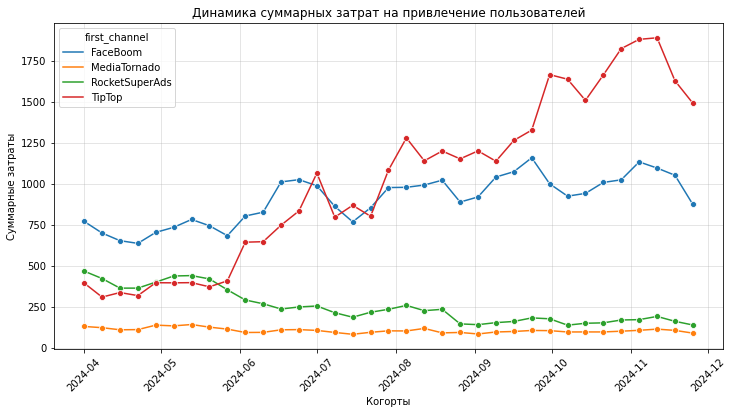

In [68]:
plt.figure(figsize=(12, 6))

# Строим линейный график 
sns.lineplot(
    data=week_costs,
    x='first_week',
    y='sum_costs',
    hue='first_channel',
    marker='o'
)

# Оформляем график
plt.grid(alpha=.4)
plt.xticks(rotation=45)

# Добавляем подписи осей
plt.xlabel('Когорты')
plt.ylabel('Суммарные затраты')

# Добавляем заголовок
plt.title('Динамика суммарных затрат на привлечение пользователей')
plt.show()

Затраты на источник привлечения TipTop постоянно растет. За исследуемый период выросли почти в 7 раз. FaceBoom затраты приблизительно на одном уровне держатся, но выше MediaTornado и RocketSuperAds. MediaTornado и RocketSuperAds низкие затраты и на одном уровне.

In [69]:
# CAC по когортам
profiles['first_week'] = profiles['first_dt'].dt.to_period('W').dt.to_timestamp()
CAC_week = profiles.groupby(['first_channel', 'first_week']).agg(
    total_users = ('user_id','nunique'),
    avg_cac = ('CAC','mean'),
).reset_index()


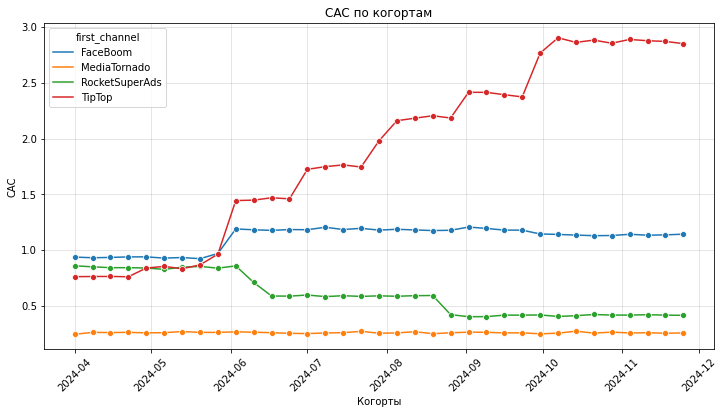

In [70]:

# Построение графика
plt.figure(figsize=(12, 6))

# Строим линейный график 
sns.lineplot(
    data=CAC_week,
    x='first_week',
    y='avg_cac',
    hue='first_channel',
    marker='o'
)

# Оформляем график
plt.grid(alpha=.4)
plt.xticks(rotation=45)

# Добавляем подписи осей
plt.xlabel('Когорты')
plt.ylabel('CAC')

# Добавляем заголовок
plt.title('CAC по когортам')
plt.show()

In [71]:
#Расчет LTV по когортам
LTV_week = events_28.groupby(['first_channel', 'first_week'])['revenue'].sum().reset_index(name='sum_revenue')


In [72]:
LTV_week['first_week'] = LTV_week['first_week'].dt.to_timestamp()

In [73]:
# Создание датафрейма ROI
ROI_week = pd.merge(LTV_week, CAC_week, on=['first_week', 'first_channel'], how='left')


In [74]:
#Расчет LTV
ROI_week['LTV']=ROI_week['sum_revenue']/ROI_week['total_users']


In [75]:
#Расчет ROI
ROI_week['ROI']=100*(ROI_week['LTV']-ROI_week['avg_cac'])/ROI_week['avg_cac']


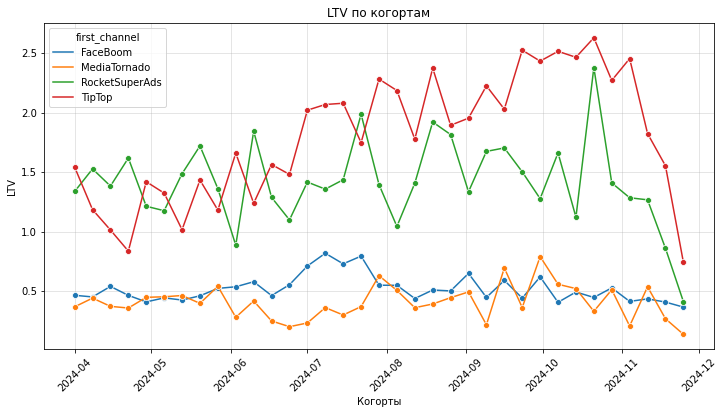

In [76]:

# Построение графика
plt.figure(figsize=(12, 6))

# Строим линейный график 
sns.lineplot(
    data=ROI_week,
    x='first_week',
    y='LTV',
    hue='first_channel',
    marker='o'
)

# Оформляем график
plt.grid(alpha=.4)
plt.xticks(rotation=45)

# Добавляем подписи осей
plt.xlabel('Когорты')
plt.ylabel('LTV')

# Добавляем заголовок
plt.title('LTV по когортам')
plt.show()

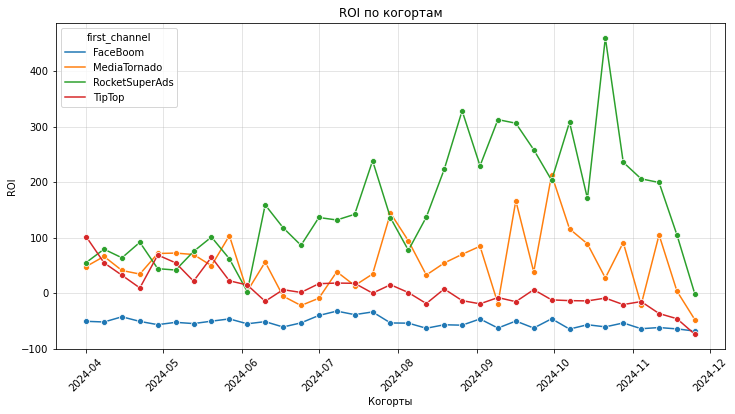

In [77]:

# Построение графика
plt.figure(figsize=(12, 6))

# Строим линейный график 
sns.lineplot(
    data=ROI_week,
    x='first_week',
    y='ROI',
    hue='first_channel',
    marker='o'
)

# Оформляем график
plt.grid(alpha=.4)
plt.xticks(rotation=45)

# Добавляем подписи осей
plt.xlabel('Когорты')
plt.ylabel('ROI')

# Добавляем заголовок
plt.title('ROI по когортам')
plt.show()

Самый дорогой и растущий CAC у TipTop. FaceBoom стабилизировался, но высок. RocketSuperAds и MediaTornado понизились после июня.

Лучший рост LTV у TipTop и RocketSuperAds. У FaceBoom рост с июня. MediaTornado на одном уровне.

RocketSuperAds и MediaTornado показывают положительную окупаемость. А вот TipTop и FaceBoom в минусе. В ноябре заметен отрицательный ROI по всем источникам привлечения.

Необходима оптимизация CAC для TipTop и FaceBoom. Искать способы для повышения LTV или сокращать бюджет. 

## Анализ периода окупаемости маркетинговых вложений



Расчитаем ROI для TipTop и FaceBoom.  

In [78]:
#Выделение когорты 
df_events['first_week']=df_events['first_dt'].dt.to_period('W').dt.to_timestamp()

In [79]:
# Выделяем неделю покупки
df_events['week'] = df_events['event_dt'].dt.to_period('W').dt.to_timestamp()

In [80]:
# Рассчитаем разницу между минимальной датой и текущей датой в неделях
df_events['n_week'] = (df_events['week'] - df_events['first_week']).dt.days / 7

In [81]:
#Недельный лайфтайм для df_users
df_users['n_week'] = (df_users['n_period'] / 7).astype(int)


In [82]:
#Суммирование выручки для расчета LTV
sum_revenue = df_events.groupby(['first_channel', 'first_week', 'n_week'])['revenue'].sum().reset_index(name='sum_rev')


In [83]:
#Сортировка для кумулятивной суммы
sum_revenue=sum_revenue.sort_values(by=['first_channel', 'n_week'])


In [84]:
# Расчет LTV как кумулятивную сумму выручки одного пользователя
sum_revenue['cumsum'] = sum_revenue.groupby(['first_channel', 'first_week'])['sum_rev'].cumsum()


In [85]:
#Для расчета LTV присоединение таблицы с количеством пользователей в 0 когорте
sum_revenue = pd.merge(sum_revenue,CAC_week, on=['first_channel','first_week'], how='left')


In [86]:
#Расчет LTV
sum_revenue['LTV'] = sum_revenue['cumsum']/sum_revenue['total_users']


In [87]:
#Расчет ROI
sum_revenue['ROI'] = 100*(sum_revenue['LTV']-sum_revenue['avg_cac'])/sum_revenue['avg_cac']


In [88]:
FaceBoom_pivot = sum_revenue[(sum_revenue['first_channel']=='FaceBoom') & (sum_revenue['n_week']<10)].pivot_table(
    index='first_week', 
    columns='n_week', 
    values='ROI'
)

# Заменим нули на NaN для корректной отрисовки
FaceBoom_pivot[FaceBoom_pivot == 0] = float('nan')
FaceBoom_pivot

n_week,0.0,1.0,2.0,3.0,4.0,5.0,6.0,7.0,8.0,9.0
first_week,,,,,,,,,,
2024-04-01,-62.249760,-54.091302,-51.371383,-50.594635,NaN,NaN,-50.206261,NaN,NaN,NaN
2024-04-08,-59.906864,-55.194990,-53.696863,-52.198737,-51.770905,-51.128442,-50.700610,NaN,NaN,NaN
2024-04-15,-52.991316,-46.341936,-44.506725,-42.443071,NaN,NaN,NaN,-41.984652,-41.526232,-40.609394
2024-04-22,-60.713083,-53.342657,-51.225587,-50.755301,-49.498585,-49.028300,NaN,NaN,NaN,NaN
2024-04-29,-64.049829,-60.007623,-58.731361,-57.880520,-56.604258,NaN,NaN,NaN,-56.178838,-55.753417
2024-05-06,-58.343344,-54.877864,-53.654993,-52.432123,NaN,-52.024500,-51.616876,NaN,NaN,NaN
2024-05-13,-64.798626,-57.529083,-55.807013,-54.659392,NaN,-53.894312,NaN,-53.129231,NaN,NaN
2024-05-20,-64.388158,-56.943403,-53.523095,-51.712027,-49.900958,-48.694028,NaN,-48.291718,-47.687580,-47.285270
2024-05-27,-58.960186,-49.977782,-48.225547,-46.911371,-46.253550,-45.377432,-44.939373,-44.501314,NaN,-43.405435


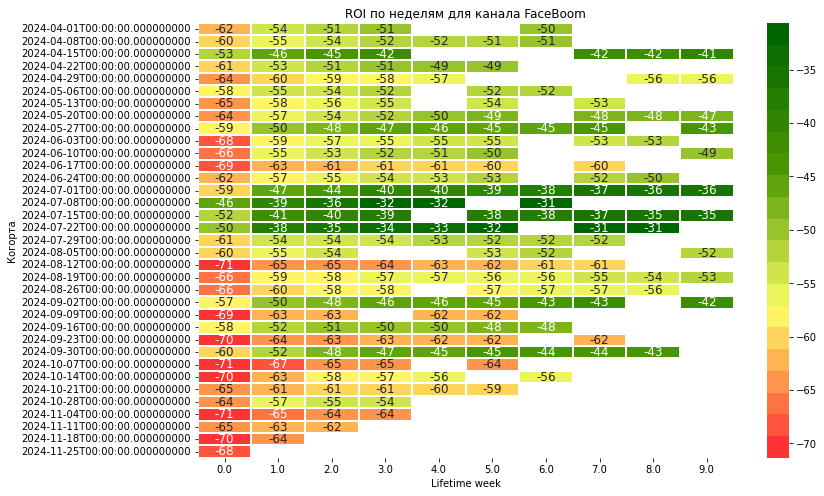

In [89]:
cmap = mcolors.LinearSegmentedColormap.from_list('green_red', ['#FF3333', '#FFFF66', '#4C9900', '#006600'], N=20)

plt.figure(figsize=(12, 8))

sns.heatmap(FaceBoom_pivot,
          cmap=cmap,
          annot=True,
          fmt='.0f',
          linewidths=2,
          annot_kws={"size": 12})

plt.title('ROI по неделям для канала FaceBoom')
plt.xlabel('Lifetime week')
plt.ylabel('Когорта')
plt.show()

In [90]:
TipTop_pivot = sum_revenue[(sum_revenue['first_channel']=='TipTop') & (sum_revenue['n_week']<10)].pivot_table(
    index='first_week', 
    columns='n_week', 
    values='ROI'
)

# Заменим нули на NaN для корректной отрисовки
TipTop_pivot[TipTop_pivot == 0] = float('nan')
TipTop_pivot

n_week,0.0,1.0,2.0,3.0,4.0,5.0,6.0,7.0,8.0,9.0
first_week,,,,,,,,,,
2024-04-01,-30.769708,25.439929,64.303921,94.670221,108.713747,121.749631,131.242273,143.016702,150.227556,161.611112
2024-04-08,-46.654057,-3.002953,30.972772,47.946039,65.895601,78.989635,89.657526,108.570410,113.422695,122.637495
2024-04-15,-48.821157,-24.194482,-1.055824,18.526475,47.477326,63.940742,75.514535,92.876713,100.441789,111.131701
2024-04-22,-57.901287,-26.792793,-9.359054,1.004142,18.437881,21.267358,28.337900,31.636856,39.810201,48.925655
2024-04-29,-39.536193,8.824750,32.747606,53.649798,74.423182,90.284197,101.990536,114.828361,126.666033,134.975386
2024-05-06,-45.140031,1.028673,28.402993,44.801270,66.376354,80.375994,92.865101,101.943487,112.914468,123.895571
2024-05-13,-41.471740,-10.031627,3.549029,15.245094,28.447317,36.747588,50.835342,57.248499,62.907316,70.213572
2024-05-20,-32.808633,7.494329,39.738315,58.818410,70.505271,95.097274,115.274360,128.171415,133.411097,143.486163
2024-05-27,-55.192168,-25.078770,-5.236494,16.433068,30.388237,38.468580,44.711811,57.198273,61.972798,77.531755


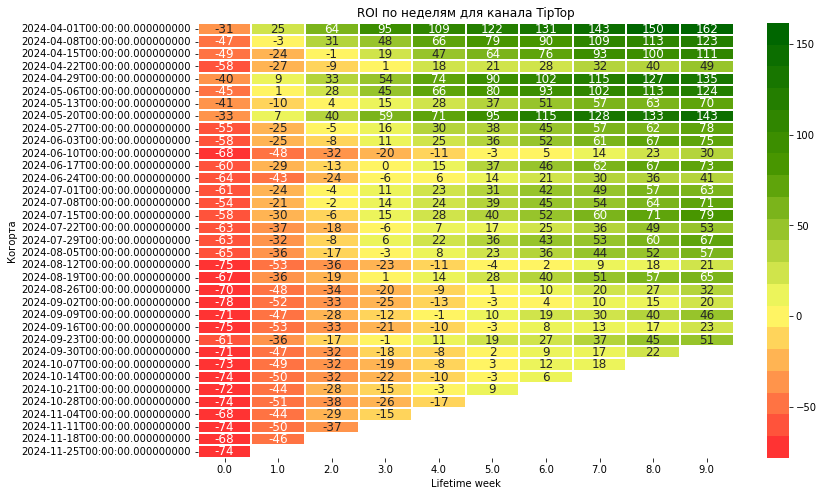

In [91]:
cmap = mcolors.LinearSegmentedColormap.from_list('green_red', ['#FF3333', '#FFFF66', '#4C9900', '#006600'], N=20)

plt.figure(figsize=(12, 8))

sns.heatmap(TipTop_pivot,
          cmap=cmap,
          annot=True,
          fmt='.0f',
          linewidths=2,
          annot_kws={"size": 12})

plt.title('ROI по неделям для канала TipTop')
plt.xlabel('Lifetime week')
plt.ylabel('Когорта')
plt.show()

Судя по тепловой карте источника FaceBoom отрицательный ROI сохраняется, но постепенно улучшается. А вот TipTop показывает улучшение в положительный ROI. Нужно снижать бюджет для FaceBoom и повышать LTV. Пользователи не генерерируют доход со временем. Возможно происходят возвраты, отмены подписок, бонусы, доход падает. TipTop имеет долгий цикл монетизации.

## Выводы и рекомендации



1. **TipTop**.
Аудитория вовлеченная, растущая, но неустойчивая в долгой монетизации. Увеличивающее скользящее удержание и конверсия в покупку. Растет LTV, но CAC еще выше. К 10 неделе показывает положительный ROI, что говорит о долгой окупаемости из-за высоких затрат.
2. **FaceBoom**.
Аудитория массовая, но нелояльная и убыточная. Низкий DAU, высокий MAU, низкий Stickiness говорят о том, что люди заходят редко, не возвращаются. Удержание низкое и на одном уровне, конверсия в покупку падает. CAC высокий, LTV растет, но не покрывает CAC. ROI отрицательный, не окупается. Пользователи приносят убытки. Каналу необходимо менять стратегию, оптимизировать затраты. 
3. **RocketSuperAds**.
Аудитория стабильная , окупаемая. Удержание на среднем уровне, конверсия увеличивающаяся. CAC снизился. LTV растет скаками. ROI самый высокий среди каналов, надежно приносит прибыль. Возможно масштабирование канала.
4. **MediaTornado**.
Аудитория стабильная без роста. Удержание на одном уровне с RocketSuperAds, но LTV ниже и практически не растет. CAC снизился. ROI второй по показателям. Поддержание аудитории.

Основная масса приходит через TipTop и FaceBoom. Долгая окупаемость - проблема в завышенном CAC и низкая монетизация. 
Стоит перераспределить бюджет в пользу RocketSuperAds и MediaTornado. Снизить CAC для TipTop и FaceBoom. Нужно повышать удержание и LTV. 
Для TipTop нужно попытаться ускорить выход в плюс к 4 неделе, а также масштабировать канал.